In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
img0 = cv2.imread("tsukuba1.png")
img1 = cv2.imread("tsukuba2.png")

img0_gray = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

In [8]:
type(img0_gray)

numpy.ndarray

In [44]:
def SSD_cul(img0, img1, window_size):
    img0 = img0.astype(np.float32)
    img1 = img1.astype(np.float32)

    height, width = img0.shape[:2]
    pad = window_size // 2

    diff_map = np.square(img0 - img1) #미리계산하고 윈도우로 내부에서 더해주기

    sad_map = np.zeros((height, width), dtype=np.float32)

    padded_diff = np.pad(diff_map, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)

    for y in range(height):
        for x in range(width):
            window = padded_diff[y:y+ window_size, x: x+ window_size]

            sad_map[y,x] = np.sum(window)

    return sad_map

In [52]:
def stereomatching(img0, img1, window_size):
    img0 = img0.astype(np.float32)
    img1 = img1.astype(np.float32)

    height, width = img0.shape[:2]
    pad = window_size // 2

    diff_map = np.square(img0 - img1) #미리계산하고 윈도우로 내부에서 더해주기

    stereo_map = np.zeros((height, width), dtype=np.float32)

    padded_diff = np.pad(diff_map, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)

    for y in range(height):
        for x in range(width):
            stereoMax = 0
            for xx in range(width):
                window = padded_diff[y:y+ window_size, xx: xx+ window_size]
                sum_win = np.sum(window)
                if(sum_win>stereoMax):
                    stereoMax = sum_win
                    stereo_map[y,x] = x-xx
    return stereo_map

In [45]:
def SAD_cul(img0, img1, window_size):
    img0 = img0.astype(np.float32)
    img1 = img1.astype(np.float32)

    height, width = img0.shape[:2]
    pad = window_size // 2

    diff_map = np.abs(img0 - img1) #미리계산하고 윈도우로 내부에서 더해주기

    sad_map = np.zeros((height, width), dtype=np.float32)

    padded_diff = np.pad(diff_map, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)

    for y in range(height):
        for x in range(width):
            window = padded_diff[y:y+ window_size, x: x+ window_size]

            sad_map[y,x] = np.sum(window)

    return sad_map

In [47]:
def normalize_and_vis(map0):
    min_val = np.min(map0)
    max_val = np.max(map0)

    norm_map = (map0 - min_val) / (max_val - min_val)

    plt.figure(figsize =(6,6))

    plt.imshow(norm_map, cmap='gray', vmin= 0, vmax=1)
    plt.show()

    return norm_map

In [48]:
window_size = 5
result = SAD_cul(img0_gray, img1_gray, window_size)

print(f"Input Shape: {img0_gray.shape}")
print(f"SAD Map Shape: {result.shape}")

Input Shape: (288, 384)
SAD Map Shape: (288, 384)


In [53]:
window_size = 5
result = stereomatching(img0_gray, img1_gray, window_size)

print(f"Input Shape: {img0_gray.shape}")
print(f"SAD Map Shape: {result.shape}")

KeyboardInterrupt: 

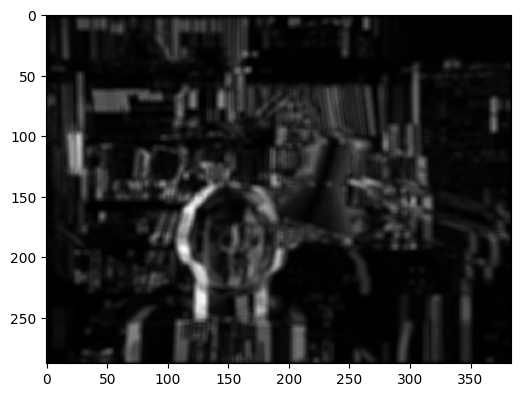

In [49]:
normalized_result = normalize_and_vis(result)

In [50]:
window_size = 5
result2 = SSD_cul(img0_gray, img1_gray, window_size)

print(f"Input Shape: {img0_gray.shape}")
print(f"SAD Map Shape: {result2.shape}")

Input Shape: (288, 384)
SAD Map Shape: (288, 384)


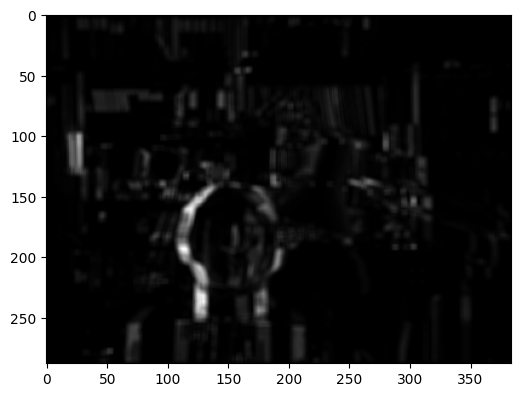

In [51]:
normalized_result = normalize_and_vis(result2)